In [1]:
!pip install openpyxl
import pandas as pd
import numpy as np
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from pathlib import Path

data_folder = Path.cwd() / "FCR_data"   # prints as the path you showed
print("Folder:", data_folder)


Folder: c:\Users\vkeenan\OneDrive - Delft University of Technology\Documents\balacing_capacity_price\FCR_data


In [ ]:

# 2. Get all .xlsx files (sorted by filename)
xlsx_files = sorted(data_folder.glob("*.xlsx"))
print("Found files:", xlsx_files)

if not xlsx_files:
    raise FileNotFoundError("No xlsx files found in FCR_data")

# 3. Read and stack them
def read_fcr_file(f):
    return pd.read_excel(f)

df_all = pd.concat((read_fcr_file(f) for f in xlsx_files),
                   ignore_index=True)

# 4. Parse dates and sort
df_all["DATE_FROM"] = pd.to_datetime(df_all["DATE_FROM"], dayfirst=True)
df_all["DATE_TO"]   = pd.to_datetime(df_all["DATE_TO"],   dayfirst=True)
df_all = df_all.sort_values("DATE_FROM")

# 5. Keep only desired columns
cols = [
    "DATE_FROM",
    "DATE_TO",
    "PRODUCT_TYPE",
    "TENDER_NUMBER",
    "PRODUCTNAME",
    "NL_SETTLEMENTCAPACITY_PRICE_[EUR/MW]",
]
df_final = df_all[cols].reset_index(drop=True)

out_path = data_folder / "FCR_merged.xlsx"  
df_final.to_excel(out_path, index=False)


In [2]:
df_final = pd.read_excel(data_folder / "FCR_merged.xlsx")

In [3]:
# all unique values
df_final["TENDER_NUMBER"].unique()

KEY_COLS = ["DATE_FROM", "DATE_TO", "PRODUCT_TYPE", "PRODUCTNAME"]
# prefer higher TENDER_NUMBER (2 over 1), then keep one per group
df_pref = (
    df_final
    .sort_values("TENDER_NUMBER", ascending=False)   # 2 before 1
    .drop_duplicates(subset=KEY_COLS, keep="first")  # keep preferred row
    .sort_values("DATE_FROM")                        # optional: sort by date
    .reset_index(drop=True)
)

In [4]:
print(df_pref.head())
print("-"*90)
print(df_pref.tail())

   DATE_FROM    DATE_TO PRODUCT_TYPE  TENDER_NUMBER   PRODUCTNAME  \
0 2020-01-01 2020-01-01          FCR              1  NEGPOS_00_24   
1 2020-01-02 2020-01-02          FCR              1  NEGPOS_00_24   
2 2020-01-03 2020-01-03          FCR              1  NEGPOS_00_24   
3 2020-01-04 2020-01-04          FCR              1  NEGPOS_00_24   
4 2020-01-05 2020-01-05          FCR              1  NEGPOS_00_24   

  NL_SETTLEMENTCAPACITY_PRICE_[EUR/MW]  
0                                  172  
1                                  174  
2                                  178  
3                                  500  
4                                  538  
------------------------------------------------------------------------------------------
      DATE_FROM    DATE_TO PRODUCT_TYPE  TENDER_NUMBER   PRODUCTNAME  \
1281 2020-12-31 2020-12-31          FCR              1  NEGPOS_20_24   
1282 2020-12-31 2020-12-31          FCR              1  NEGPOS_16_20   
1283 2020-12-31 2020-12-31      

C:\Users\vkeenan\AppData\Local\Temp\ipykernel_19792\1556715910.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_plot[price_col].replace("-", np.nan),


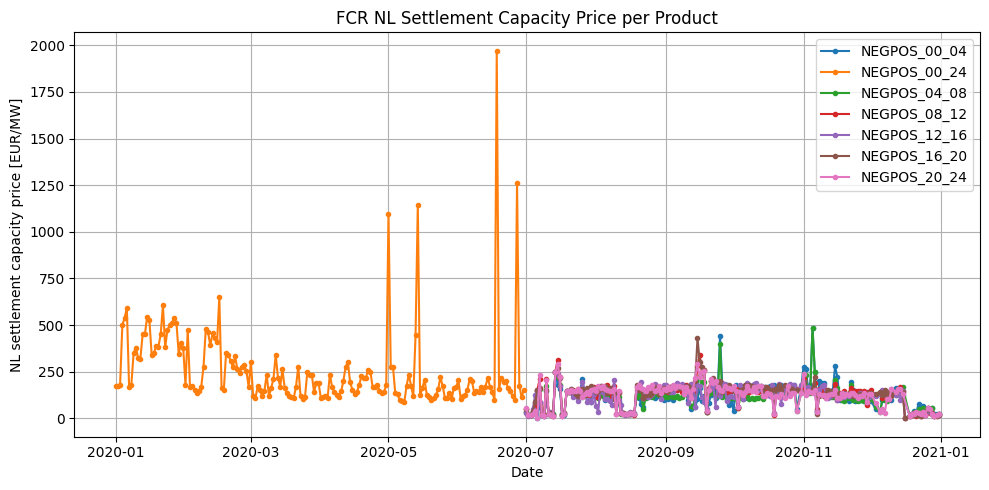

In [5]:
df_plot = df_pref.copy()

# dates
df_plot["DATE_FROM"] = pd.to_datetime(df_plot["DATE_FROM"])

# numeric prices (turn "-" and other non-numeric stuff into NaN)
price_col = "NL_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"
df_plot[price_col] = pd.to_numeric(
    df_plot[price_col].replace("-", np.nan),
    errors="coerce"
)

# drop rows without a price
df_plot = df_plot.dropna(subset=[price_col])

# ---- plot: one line per PRODUCTNAME ----
plt.figure(figsize=(10, 5))

for name, g in df_plot.groupby("PRODUCTNAME"):
    plt.plot(g["DATE_FROM"], g[price_col], marker=".", label=name)

plt.xlabel("Date")
plt.ylabel("NL settlement capacity price [EUR/MW]")
plt.title("FCR NL Settlement Capacity Price per Product")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


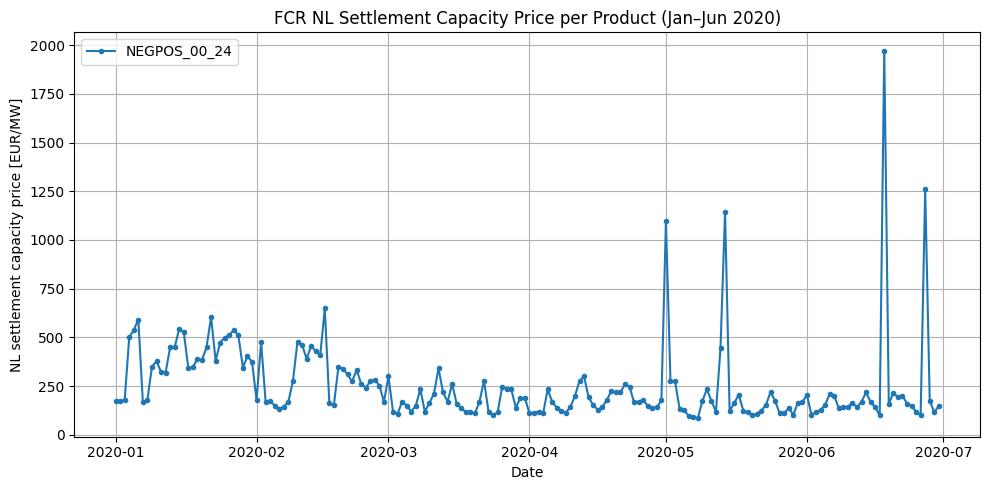

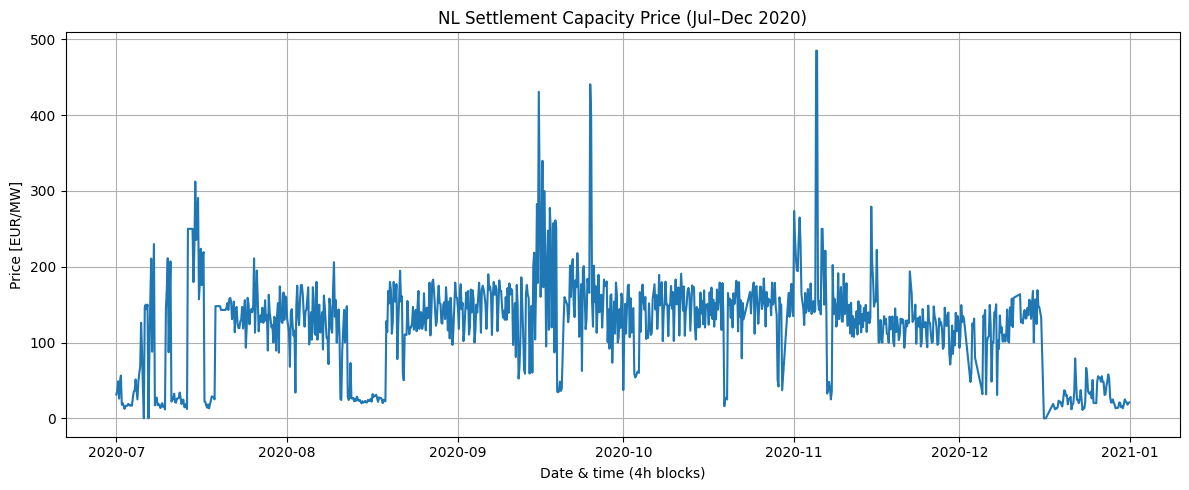

In [6]:
cutoff = pd.Timestamp("2020-07-01")
df_before = df_plot[df_plot["DATE_FROM"] < cutoff]

# Graph 1: until end of June 
plt.figure(figsize=(10,5))
for name, g in df_before.groupby("PRODUCTNAME"):
    plt.plot(g["DATE_FROM"], g[price_col], marker=".", label=name)

plt.title("FCR NL Settlement Capacity Price per Product (Jan–Jun 2020)")
plt.xlabel("Date")
plt.ylabel("NL settlement capacity price [EUR/MW]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#------------------------------------------------------------------------------------------------------

# Graph 2: from July to December

df_jul_dec = df_plot[df_plot["DATE_FROM"] >= "2020-07-01"].copy()

# extract start hour from PRODUCTNAME (NEGPOS_04_08 -> 4, etc.)
df_jul_dec["start_hour"] = (
    df_jul_dec["PRODUCTNAME"].str.split("_").str[1].astype(int)
)

# full timestamp = date + start hour
df_jul_dec["timestamp"] = (
    df_jul_dec["DATE_FROM"] + pd.to_timedelta(df_jul_dec["start_hour"], "h")
)

# sort chronologically
df_jul_dec = df_jul_dec.sort_values("timestamp")

price_col = "NL_SETTLEMENTCAPACITY_PRICE_[EUR/MW]"

# make sure it's clean and sorted
df_jul_dec = df_jul_dec.sort_values("timestamp").copy()
df_jul_dec[price_col] = pd.to_numeric(
    df_jul_dec[price_col].replace("-", np.nan), errors="coerce"
)
df_jul_dec = df_jul_dec.dropna(subset=[price_col])

plt.figure(figsize=(12,5))
plt.plot(df_jul_dec["timestamp"], df_jul_dec[price_col], linestyle="-")
plt.title("NL Settlement Capacity Price (Jul–Dec 2020)")
plt.xlabel("Date & time (4h blocks)")
plt.ylabel("Price [EUR/MW]")
plt.grid(True)
plt.tight_layout()
plt.show()